In [1]:
import re
import unicodedata

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score

from transformers import AutoTokenizer, AutoModel
from pythainlp.tokenize import word_tokenize

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import coalesce  

import matplotlib.pyplot as plt
import networkx as nx
import pickle
import warnings
from collections import Counter


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================
# Load & clean data
# =========================
df = pd.read_csv('AFNC_news_dataset_tf-2.csv')



In [3]:
# กำหนด mapping dictionary
label_map = {
    'ข่าวจริง': 'true',
    'ข่าวปลอม': 'fake',
}

In [4]:
# 1. ล้างเว้นวรรคผีหลอก และแปลงเป็น String
df['ประเภทข่าว'] = df['ประเภทข่าว'].astype(str).str.strip()
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].astype(str).str.strip()

# 2. ปราบมาร: กรองแถวที่มีคำว่า 'nan', 'NaN', '', 'None' ทิ้งไปให้หมด
df = df[~df['ประเภทข่าว'].isin(['nan', 'NaN', '', 'None'])]
df = df[~df['หมวดหมู่ของข่าว'].isin(['nan', 'NaN', '', 'None'])]
df = df.dropna(subset=['หัวข้อข่าว', 'ประเภทข่าว', 'หมวดหมู่ของข่าว']).reset_index(drop=True)

# =======================================================
# 3. จัดการ Label (ข่าวจริง = 0, ข่าวปลอม = 1)
# =======================================================
# บังคับ Map ให้เป็น 0 กับ 1 เลยครับ โมเดล ML จะชอบแบบนี้ที่สุด
label2id = {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
id2label = {0: 'ข่าวจริง', 1: 'ข่าวปลอม'}

df['label_id'] = df['ประเภทข่าว'].map(label2id)

# ตัดแถวที่ Map ไม่ผ่านทิ้ง (เพื่อความชัวร์ 100%)
df = df.dropna(subset=['label_id']).reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)

print(f"✅ Label Classes: {label2id}")

✅ Label Classes: {'ข่าวจริง': 0, 'ข่าวปลอม': 1}


In [5]:
# ทำความสะอาด label ลบอิโมจิ และแมปค่า 
# Normalization Function

# Remove zero-width characters  
ZW = ''.join(['\u200B', '\u200C', '\u200D', '\uFEFF'])


def normalize_thai(s):
    if pd.isna(s):
        return None
    #non-breaking space
    s = str(s).replace('\u00A0', ' ').translate({ord(ch): None for ch in ZW})
    s = unicodedata.normalize('NFC', s)
    s = re.sub(r'\s+', ' ', s).strip()
    # collapse repeated diacritics/marks
    s = re.sub(r'([\u0E31\u0E34-\u0E3A\u0E47-\u0E4E])\1+', r'\1', s)
    return s

df['ประเภทข่าว'] = df['ประเภทข่าว'].apply(normalize_thai) #print
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].apply(normalize_thai)


In [6]:
# โหลดโมเดลภาษาไทย + จัด device WangchanBERTa
model_WCB = "airesearch/wangchanberta-base-att-spm-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_WCB, use_fast=False)
#WangchanBERTa
lm_model = AutoModel.from_pretrained(model_WCB)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#ย้ายไปdevice    
lm_model = lm_model.to(device).eval()


In [7]:
# ดูตัวอย่าง content (raw text)
print("\nSample of content:")
print(df[['หัวข้อข่าว']].head(1))

# ถ้าต้องการสถิติ token length จาก BERT tokenizer
encoded_inputs = tokenizer(
    df['หัวข้อข่าว'].tolist(),
    padding=False,
    truncation=False,
    return_tensors=None
)

token_lengths = [len(tokens) for tokens in encoded_inputs['input_ids']]
print("\nToken statistics (from WangchanBERTa tokenizer):")
print(f"Average tokens in หัวข้อข่าว: {sum(token_lengths)/len(token_lengths):.2f}")

#--- TRUE NEWS SAMPLES ---
print("\nSample of true news content:")
print(df[df['label_binary'] == 'true'][['หัวข้อข่าว', 'label_binary']].head(2))

#--- FAKE NEWS SAMPLES ---
print("\nSample of fake news content:")
print(df[df['label_binary'] == 'fake'][['หัวข้อข่าว', 'label_binary']].head(2))



Sample of content:
                                          หัวข้อข่าว
0  กินหน่อไม้สดปริมาณมาก เสี่ยงรับพิษจากสารไซยาไน...

Token statistics (from WangchanBERTa tokenizer):
Average tokens in หัวข้อข่าว: 20.78

Sample of true news content:
                                           หัวข้อข่าว label_binary
21  รอรถเมล์นานสามารถร้องเรียนได้ที่เพจ ขสมก. พร้อ...         true
23  ดื่มชาที่ร้อนเกินไป เสี่ยงเป็นโรคมะเร็งหลอดอาห...         true

Sample of fake news content:
                                           หัวข้อข่าว label_binary
19   ดื่มนมเยอะ มีผลเสียต่อร่างกาย ทำให้เป็นหลากหล...         fake
20        ต้านโควิด-19 ได้ด้วย มันเทศญี่ปุ่นต้มน้ำขิง         fake


In [8]:
# -------------------------------------------
# ฟังก์ชันสร้าง BERT Embedding WangchanBERT
# -------------------------------------------
#Decorator 
@torch.no_grad()
def get_bert_embeddings_batch(
    texts,
    tokenizer,
    model,
    device,
    max_length=256,
    batch_size=32,
    use_mean_pool=True,
):
    """
    สร้าง BERT embeddings แบบ batch สำหรับลิสต์ของข้อความ (texts)
    คืนค่าเป็น numpy array รูป (N, hidden_size)
    """
    model.eval()  # ให้แน่ใจว่าอยู่ในโหมด eval

    all_embeddings = []

    # loop ทีละ batch
    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        # กัน NaN / non-string
        batch_texts = [
            "" if (isinstance(t, float) and np.isnan(t)) else str(t)
            for t in batch_texts
        ]

        # Tokenize ทั้ง batch
        inputs = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,          # padding ตาม batch
            max_length=max_length,
            return_tensors='pt'
        ).to(device)

        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state   # (B, seq_len, hidden)

        if use_mean_pool:
            # mean pooling ตาม attention mask
            attn = inputs['attention_mask'].unsqueeze(-1)      # (B, seq_len, 1)
            summed = (last_hidden * attn).sum(dim=1)           # (B, hidden)
            denom = attn.sum(dim=1).clamp(min=1)               # (B, 1)
            emb = (summed / denom).cpu().numpy()               # (B, hidden)
        else:
            # ใช้ CLS token
            emb = last_hidden[:, 0, :].cpu().numpy()           # (B, hidden)

        all_embeddings.append(emb)

    # รวมทุก batch เข้าด้วยกัน
    return np.vstack(all_embeddings)   # (N, hidden_size)


In [9]:
# =======================================================
# 3. จัดการ Label (ข่าวจริง = 0, ข่าวปลอม = 1)
# =======================================================
# บังคับ Map ให้เป็น 0 กับ 1 เลยครับ โมเดล ML จะชอบแบบนี้ที่สุด
label2id = {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
id2label = {0: 'ข่าวจริง', 1: 'ข่าวปลอม'}

df['label_id'] = df['ประเภทข่าว'].map(label2id)

# ตัดแถวที่ Map ไม่ผ่านทิ้ง (เพื่อความชัวร์ 100%)
df = df.dropna(subset=['label_id']).reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)

print(f"✅ Label Classes: {label2id}")

# =======================================================
# 4. จัดการ Category (หมวดหมู่ของข่าว)
# =======================================================
cats = sorted(df['หมวดหมู่ของข่าว'].unique())
cat2id = {c: i for i, c in enumerate(cats)}
id2cat = {i: c for c, i in cat2id.items()}

df['category_id'] = df['หมวดหมู่ของข่าว'].map(cat2id)
print(f"✅ Category Classes สร้างสำเร็จ ({len(cats)} หมวดหมู่)")

# =======================================================
# 5. ปรับสมดุลข้อมูล (Balancing Data) ให้เป็น 5,744 ข่าว
# =======================================================
# แยกกลุ่มข่าวจริงและข่าวปลอม
df_true = df[df['label_id'] == 0]
df_fake = df[df['label_id'] == 1]

print(f"\n📊 ก่อนปรับสมดุล: ข่าวจริง = {len(df_true)} ข่าว, ข่าวปลอม = {len(df_fake)} ข่าว")

# หาจำนวนของกลุ่มที่น้อยที่สุด (เพื่อให้ข้อมูล Balance กันเป๊ะๆ)
min_len = min(len(df_true), len(df_fake))

# สุ่มข้อมูลให้เท่ากับ min_len
df_true_sampled = df_true.sample(n=min_len, random_state=42)
df_fake_sampled = df_fake.sample(n=min_len, random_state=42)

# นำมาต่อกันแล้วสับไพ่ (Shuffle) ให้ข้อมูลกระจายตัว
df_balanced = pd.concat([df_true_sampled, df_fake_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"⚖️ หลังปรับสมดุล (รวมทั้งหมด {len(df_balanced)} ข่าว):")
print(df_balanced['ประเภทข่าว'].value_counts())
print("="*80)

✅ Label Classes: {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
✅ Category Classes สร้างสำเร็จ (8 หมวดหมู่)

📊 ก่อนปรับสมดุล: ข่าวจริง = 2872 ข่าว, ข่าวปลอม = 8237 ข่าว
⚖️ หลังปรับสมดุล (รวมทั้งหมด 5744 ข่าว):
ประเภทข่าว
ข่าวจริง    2872
ข่าวปลอม    2872
Name: count, dtype: int64


In [10]:

# ====================================================================
# 2. สร้าง BERT Embedding จาก content
# ====================================================================

# เตรียมข้อความ
texts = df['หัวข้อข่าว'].fillna("").astype(str).tolist()

print("\nCreating BERT Embeddings for Content (batch)...")
# เรียกฟังก์ชัน embedding (สมมติว่ามีฟังก์ชันนี้อยู่แล้ว)
content_emb = get_bert_embeddings_batch(
    texts,
    tokenizer=tokenizer,
    model=lm_model,
    device=device,
    max_length=256,
    batch_size=32,
    use_mean_pool=True,
)

print("content_emb shape:", content_emb.shape)  # เช่น (N, 768)

# Normalize
x_np = normalize(content_emb, axis=1, norm='l2')

# ====================================================================
# 3. กำหนดตัวแปร Target (เรียกใช้จากคอลัมน์ที่สร้างไว้)
# ====================================================================

# ✅ เรียกใช้ได้แล้ว เพราะเราสร้างคอลัมน์ไว้ข้างบนแล้ว
y_np = df['label_id'].values
y_cat_np = df['category_id'].values

print("-" * 30)
print("x_np shape (ก่อน balanced):", x_np.shape)
print("y_np shape (ก่อน balanced):", y_np.shape)
print(f"จำนวนตัวอย่างก่อน balanced (real/fake): {np.unique(y_np, return_counts=True)}")


Creating BERT Embeddings for Content (batch)...


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


content_emb shape: (11109, 768)
------------------------------
x_np shape (ก่อน balanced): (11109, 768)
y_np shape (ก่อน balanced): (11109,)
จำนวนตัวอย่างก่อน balanced (real/fake): (array([0, 1]), array([2872, 8237]))


In [11]:
# ====================================================================
# 1. เตรียมข้อมูลแบบ Balanced (พร้อมโชว์ตัวอย่างข่าว หัว/ท้าย)
# ====================================================================

print("🔄 1. Balancing Data (Final Version)...")

# ✅ เริ่มกระบวนการ
df.columns = df.columns.str.strip()
date_col = 'วันและเวลาที่เผยแพร่'

# --- 🛠️ ฟังก์ชันแปลงวันที่ (Surgical Fix) ---
def convert_thai_date_final(date_str):
    if pd.isna(date_str): return pd.NaT
    s = str(date_str).strip()
    if s == 'NaT': return pd.NaT
    if ' ' in s: s = s.split(' ')[0] # ตัดเวลาทิ้ง
    if '/' in s:
        parts = s.split('/') 
        new_parts = []
        for p in parts:
            if p.isdigit() and len(p) == 4 and int(p) > 2400: # แก้ปี พ.ศ.
                new_parts.append(str(int(p) - 543))
            else:
                new_parts.append(p)
        return "-".join(new_parts)
    return s

# --- 🔥 แปลงข้อมูล ---
if date_col in df.columns:
    df['temp_date_str'] = df[date_col].apply(convert_thai_date_final)
    df['parsed_date'] = pd.to_datetime(df['temp_date_str'], dayfirst=True, errors='coerce')
    sort_col = 'parsed_date'
else:
    sort_col = None

# แยก Index
idx_real = np.where(y_np == 0)[0]
idx_fake = np.where(y_np == 1)[0]
min_len = min(len(idx_real), len(idx_fake))

# --- 🔥 คัดเลือกและแสดงผล ---
if sort_col and df[sort_col].notna().sum() > 0:
    
    # ==========================
    # ❌ ส่วนของข่าวปลอม (Fake)
    # ==========================
    df_fake_rows = df.iloc[idx_fake]
    df_fake_sorted = df_fake_rows.sort_values(by=sort_col, ascending=False)
    df_fake_kept = df_fake_sorted.head(min_len) # ตัดเอาเฉพาะจำนวนที่ต้องการ
    idx_fake_balanced = df_fake_kept.index.to_numpy()

    print("\n" + "="*80)
    print(f"❌ ANALYZING FAKE NEWS (ข่าวปลอม) - Total: {min_len} items")
    print("="*80)
    
    print(f"\n📌 5 ข่าวปลอม 'ล่าสุด' (Newest):")
    # แสดง วันที่เดิม | วันที่แปลงแล้ว | หัวข้อข่าว
    print(df_fake_kept[[date_col, 'parsed_date', 'หัวข้อข่าว']].head(5).to_string(index=False))
    
    print(f"\n📌 5 ข่าวปลอม 'เก่าที่สุด' ที่เลือกมา (Oldest Kept):")
    print(df_fake_kept[[date_col, 'parsed_date', 'หัวข้อข่าว']].tail(5).to_string(index=False))

    # ==========================
    # ✅ ส่วนของข่าวจริง (Real)
    # ==========================
    df_real_rows = df.iloc[idx_real]
    df_real_sorted = df_real_rows.sort_values(by=sort_col, ascending=False)
    df_real_kept = df_real_sorted.head(min_len)
    idx_real_balanced = df_real_kept.index.to_numpy()
    
    print("\n" + "="*80)
    print(f"✅ ANALYZING REAL NEWS (ข่าวจริง) - Total: {min_len} items")
    print("="*80)

    print(f"\n📌 5 ข่าวจริง 'ล่าสุด' (Newest):")
    print(df_real_kept[[date_col, 'parsed_date', 'หัวข้อข่าว']].head(5).to_string(index=False))

    print(f"\n📌 5 ข่าวจริง 'เก่าที่สุด' ที่เลือกมา (Oldest Kept):")
    print(df_real_kept[[date_col, 'parsed_date', 'หัวข้อข่าว']].tail(5).to_string(index=False))
    print("="*80)

else:
    print("⚠️ วันที่ใช้การไม่ได้ ใช้วิธีตัดตาม Index เดิม")
    idx_fake_balanced = idx_fake[:min_len]
    idx_real_balanced = idx_real[:min_len]

# รวมข้อมูล
idx_balanced = np.concatenate([idx_real_balanced, idx_fake_balanced])
x_balanced = x_np[idx_balanced]
y_balanced = y_np[idx_balanced]

if 'y_cat_np' in globals():
    y_cat_balanced = y_cat_np[idx_balanced]

N_balanced = x_balanced.shape[0] 
print(f"\n✅ Final Balanced Dataset Size: {N_balanced} samples")

🔄 1. Balancing Data (Final Version)...

❌ ANALYZING FAKE NEWS (ข่าวปลอม) - Total: 2872 items

📌 5 ข่าวปลอม 'ล่าสุด' (Newest):
วันและเวลาที่เผยแพร่ parsed_date                                                                          หัวข้อข่าว
 11/12/2568 03:30:20  2025-12-11                            เปิดวิธียืนยันตัวตนที่ตู้กรุงไทย ATM คนละครึ่งพลัส เฟส 2
 11/12/2568 09:00:52  2025-12-11                                          ทหารกัมพูชา วางอาวุธและยกมือแสดงการยอมจำนน
 10/12/2568 09:30:45  2025-12-10 ไทยเป็นฝ่ายเริ่มรุกราน และใช้อาวุธทุกชนิดโจมตีต่อเนื่อง เพื่อยั่วยุให้กัมพูชาโต้ตอบ
 10/12/2568 03:30:25  2025-12-10      เชิญชวนแอดไลน์ pttservice_or ที่รับรองจาก ก.ล.ต. เพื่อรับรายละเอียดการลงทุนฟรี
 10/12/2568 04:30:21  2025-12-10                          ไข่ไก่ที่วางขายตามตลาด เป็นไข่ปลอมที่ผลิตโดยโรงงานขนาดเล็ก

📌 5 ข่าวปลอม 'เก่าที่สุด' ที่เลือกมา (Oldest Kept):
วันและเวลาที่เผยแพร่ parsed_date                                                                                       


📊 Starting Data Analysis...

✅ 1. Creating Overall Distribution Graph...
หมวดหมู่ของข่าว
นโยบายรัฐบาล-ข่าวสาร    4838
ผลิตภัณฑ์สุขภาพ         2967
การเงิน-หุ้น            2271
ภัยพิบัติ                507
ความสงบและความมั่นคง     418
ข่าวอื่นๆ                 92
เศรษฐกิจ                  14
ยาเสพติด                   2
Name: count, dtype: int64


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_20840\3876794720.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


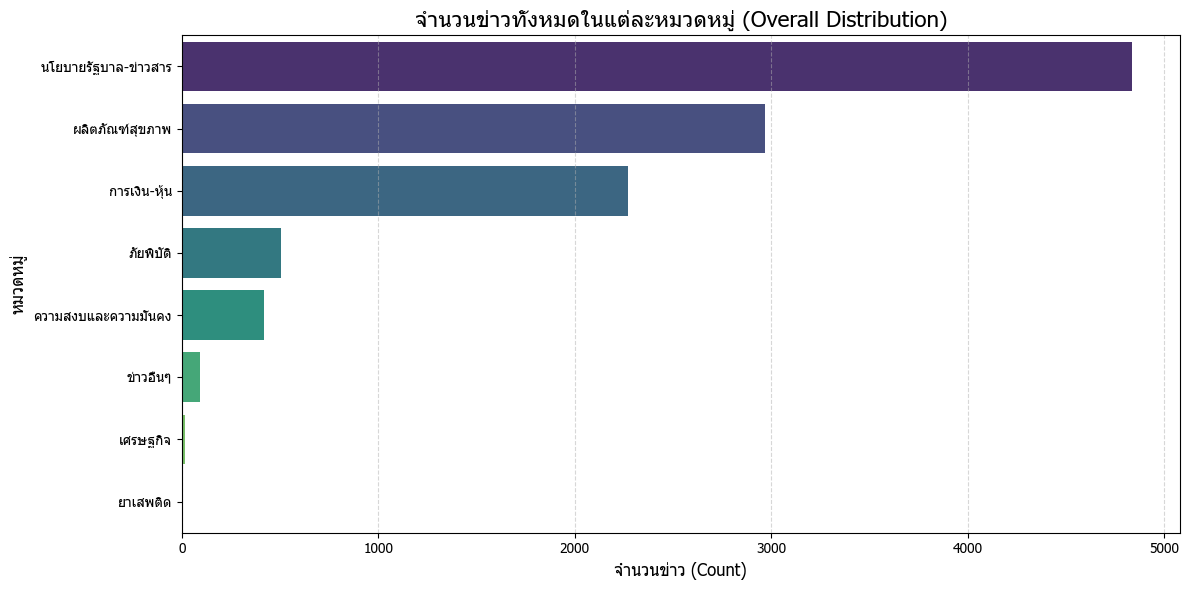


✅ 2. Creating Comparison Graph (Real vs Fake)...
label_binary          fake  true
หมวดหมู่ของข่าว                 
การเงิน-หุ้น          2158   111
ข่าวอื่นๆ               83     9
ความสงบและความมั่นคง   310    57
นโยบายรัฐบาล-ข่าวสาร  2692  2128
ผลิตภัณฑ์สุขภาพ       2629   335
ภัยพิบัติ              354   151
ยาเสพติด                 0     2
เศรษฐกิจ                11     3


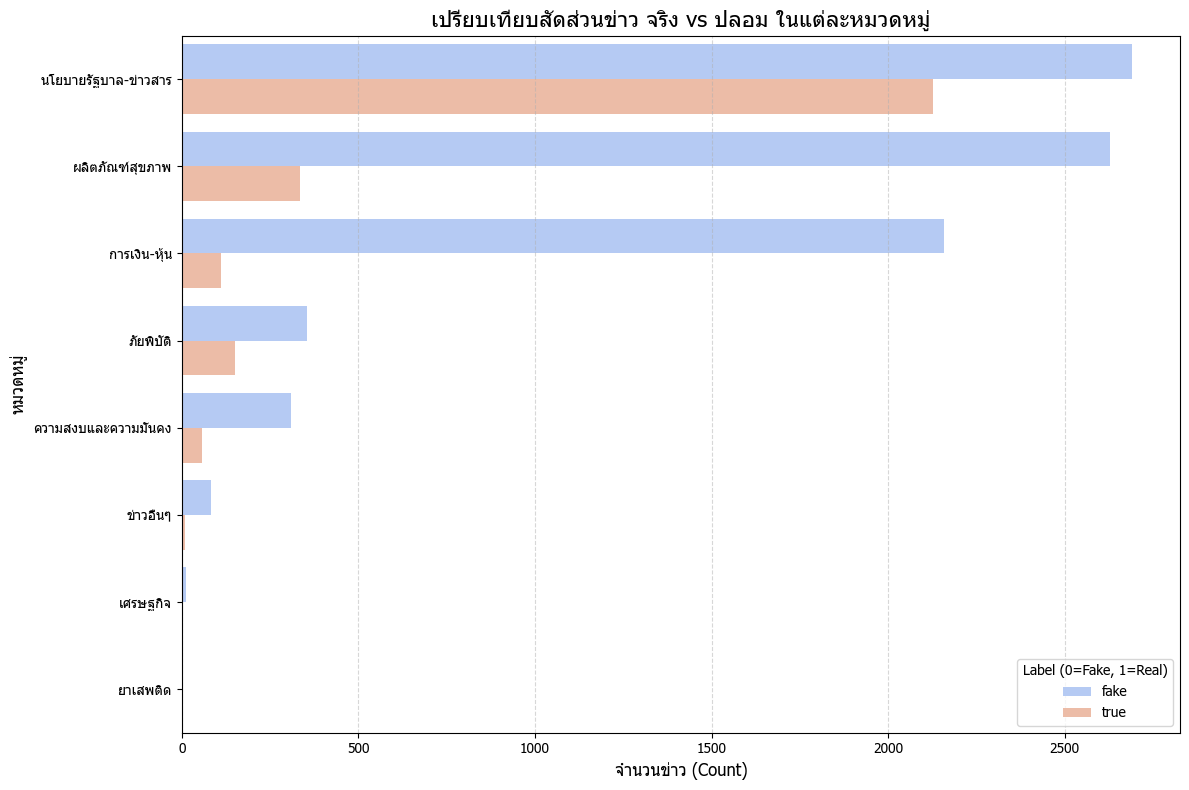


✅ Saved graphs: graph_category_total.png, graph_category_comparison.png


In [12]:
# ====================================================================
# 📊 DATA ANALYSIS & VISUALIZATION (ฉบับครบ 2 กราฟ)
# ====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n📊 Starting Data Analysis...")

# --- 1. ตั้งค่าตัวแปรชื่อคอลัมน์ (ตรวจสอบให้ตรงกับไฟล์ CSV) ---
col_category = 'หมวดหมู่ของข่าว'   # ชื่อคอลัมน์หมวดหมู่
col_label = 'label_binary'       # ชื่อคอลัมน์เฉลย (0, 1)

# --- 2. ตั้งค่าฟอนต์ภาษาไทย ---
try:
    plt.rcParams['font.family'] = 'Tahoma' # Windows ใช้ Tahoma
except:
    pass

if col_category in df.columns:
    
    # ============================================================
    # 🟢 กราฟที่ 1: ดูภาพรวม (Overall Distribution) - อันเดิมที่คุณต้องการเก็บไว้
    # ============================================================
    print(f"\n✅ 1. Creating Overall Distribution Graph...")
    
    # นับจำนวนและปริ้นท์
    category_counts = df[col_category].value_counts()
    print(category_counts)
    
    plt.figure(figsize=(12, 6)) # สร้างหน้ากระดาษใหม่
    sns.countplot(
        y=df[col_category], 
        order=df[col_category].value_counts().index,
        palette='viridis' # สีโทนเขียว-ม่วง (ดูภาพรวม)
    )
    plt.title('จำนวนข่าวทั้งหมดในแต่ละหมวดหมู่ (Overall Distribution)', fontsize=16)
    plt.xlabel('จำนวนข่าว (Count)', fontsize=12)
    plt.ylabel('หมวดหมู่', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    #plt.savefig('graph_category_total.png') # เซฟรูปที่ 1
    plt.show() # โชว์รูปที่ 1


    # ============================================================
    # 🔴 กราฟที่ 2: เปรียบเทียบ จริง vs ปลอม (Real vs Fake Comparison)
    # ============================================================
    if col_label in df.columns:
        print(f"\n✅ 2. Creating Comparison Graph (Real vs Fake)...")
        
        # ปริ้นท์ตารางตัวเลขเทียบดู
        cross_tab = pd.crosstab(df[col_category], df[col_label])
        print(cross_tab)
        
        plt.figure(figsize=(12, 8)) # สร้างหน้ากระดาษใหม่
        sns.countplot(
            data=df,
            y=col_category,
            hue=col_label,       # 🔥 แยกสีตามจริง/ปลอม
            order=df[col_category].value_counts().index, # เรียงตามกราฟแรก
            palette='coolwarm'   # สีโทนร้อน/เย็น (แยกความต่าง)
        )
        
        plt.title('เปรียบเทียบสัดส่วนข่าว จริง vs ปลอม ในแต่ละหมวดหมู่', fontsize=16)
        plt.xlabel('จำนวนข่าว (Count)', fontsize=12)
        plt.ylabel('หมวดหมู่', fontsize=12)
        plt.legend(title='Label (0=Fake, 1=Real)', loc='lower right')
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        #plt.savefig('graph_category_comparison.png') # เซฟรูปที่ 2
        plt.show() # โชว์รูปที่ 2
        
    print("\n✅ Saved graphs: graph_category_total.png, graph_category_comparison.png")

else:
    print(f"⚠️ ไม่พบคอลัมน์ '{col_category}' ข้ามขั้นตอนสร้างกราฟ")

print("====================================================================")

In [13]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def build_spatio_temporal_graph(df, text_embeddings, threshold=0.5, decay_rate=0.05):
    # --- 1. จัดการวันที่และค่าว่าง ---
    # แปลงเป็น datetime (ค่าที่แปลงไม่ได้จะกลายเป็น NaT)
    publish_dates = pd.to_datetime(df['publish_date'], errors='coerce')
    
    # แทนที่ NaT ด้วยค่ามัธยฐาน (Median)
    median_date = publish_dates.median()
    publish_dates = publish_dates.fillna(median_date)
    
    # แปลงเป็นหน่วย "วัน" (Timestamp เป็นวินาที หารด้วยจำนวนวินาทีใน 1 วัน)
    time_values = publish_dates.view('int64').values / 10**9 / 86400 
    
    # --- 2. คำนวณ Spatial Similarity (จาก WangchanBERTa) ---
    spatial_sim = cosine_similarity(text_embeddings)
    
    # --- 3. คำนวณ Temporal Weight (Exponential Decay) ---
    # คำนวณความต่างของวันระหว่างทุกคู่ข่าว
    time_diff = np.abs(time_values.reshape(-1, 1) - time_values.reshape(1, -1))
    # ยิ่งห่างกัน Weight ยิ่งเข้าใกล้ 0
    temporal_weight = np.exp(-decay_rate * time_diff)
    
    # --- 4. ผสมผสาน (Fusion) ---
    final_adj = spatial_sim * temporal_weight
    
    # ตัดเส้นเชื่อมที่เบาเกินไปทิ้ง (Sparse Graph)
    final_adj[final_adj < threshold] = 0
    
    # --- 5. แปลงเป็นรูปแบบ PyTorch Geometric ---
    adj_sparse = torch.tensor(final_adj, dtype=torch.float)
    # หาตำแหน่งที่มีเส้นเชื่อม (edge_index) และค่าน้ำหนัก (edge_weight)
    edge_index = adj_sparse.nonzero().t().contiguous()
    edge_weight = adj_sparse[edge_index[0], edge_index[1]]
    
    return edge_index, edge_weight

# วิธีใช้งาน:
# edge_index, edge_weight = build_spatio_temporal_graph(df_test, xlm_embeddings)
# data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y)

In [14]:
# ====================================================================
# GCN Model Definition 
# ====================================================================
class GCNNet(nn.Module):
    def __init__(self, num_node_features, num_classes, hidden_channels=256, dropout_rate=0.4):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # ถ้ามี edge weights ให้ใช้
        edge_weight = getattr(data, 'edge_attr', None)
        
        # Layer 1
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        # Layer 2
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        
        return x  # logits (ส่งไปเข้า CrossEntropyLoss)


# ====================================================================
# Evaluation Function
# ====================================================================
def evaluate_masked(logits, mask, data):
    # เปลี่ยน logits เป็น class prediction (0 หรือ 1)
    y_pred = logits[mask].argmax(dim=1).cpu().numpy()
    y_true = data.y[mask].cpu().numpy()
    
    # คำนวณ Metrics พื้นฐาน
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    # (Optional) ถ้าอยากเห็น Report ละเอียดให้ print ออกมาดูได้
    # print(classification_report(y_true, y_pred, target_names=['News Real', 'News Fake'], digits=4))
    
    return acc, f1m

In [15]:
# ====================================================================
# 2. สร้าง kNN Graph จากข้อมูล Balanced
# ====================================================================
k = 10
print(f"--- 2. Building kNN Graph with k={k} ---")

# 2.1 Fit kNN ด้วย x_balanced
nbrs = NearestNeighbors(n_neighbors=k, metric='cosine').fit(x_balanced)
dists, indices = nbrs.kneighbors(x_balanced) 

# 2.2 Create edges
src = np.repeat(np.arange(N_balanced), k-1)
dst = indices[:, 1:].reshape(-1)
w = 1.0 - dists[:, 1:].reshape(-1)

# 2.3 Make undirected
edge_index_np = np.vstack([src, dst])
edge_index_np_rev = edge_index_np[::-1, :]
edge_index_np = np.concatenate([edge_index_np, edge_index_np_rev], axis=1)
edge_weight_np = np.concatenate([w, w], axis=0)

# แปลงเป็น Tensor
edge_index = torch.tensor(edge_index_np, dtype=torch.long)
edge_weight = torch.tensor(edge_weight_np, dtype=torch.float)

# 2.4 Coalesce
try:
    edge_index, edge_weight = coalesce(
    edge_index, 
    edge_weight, 
    num_nodes=N_balanced, 
    reduce='mean'
)
except Exception as e:
    print(f"Warning: coalesce failed ({e})")

# ====================================================================
# 3. แบ่ง Train/Val/Test และสร้าง Data Object
# ====================================================================
print("\n✂️ 3. Splitting Train/Val/Test (on Balanced Data)...")

x_tensor = torch.tensor(x_balanced, dtype=torch.float)
y_tensor = torch.tensor(y_balanced, dtype=torch.long)
idx_all = np.arange(N_balanced)

idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, stratify=y_balanced, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, stratify=y_balanced[idx_temp], random_state=42)

train_mask = torch.zeros(N_balanced, dtype=torch.bool); train_mask[idx_train] = True
val_mask   = torch.zeros(N_balanced, dtype=torch.bool); val_mask[idx_val]   = True
test_mask  = torch.zeros(N_balanced, dtype=torch.bool); test_mask[idx_test]  = True

data = Data(
    x=x_tensor, 
    y=y_tensor, 
    edge_index=edge_index, 
    edge_attr=edge_weight.float(),  # บังคับเป็น float เพื่อความชัวร์
    train_mask=train_mask, 
    val_mask=val_mask, 
    test_mask=test_mask
)

# ย้ายไป device (GPU/CPU) ทีเดียวทั้งก้อน
data = data.to(device)

print(f"✅ Data Object Ready! Edge attributes shape: {data.edge_attr.shape}")

print(f"Nodes: {data.num_nodes}, Edges: {data.num_edges}")
print(f"Train: {train_mask.sum().item()} | Val: {val_mask.sum().item()} | Test: {test_mask.sum().item()}")

--- 2. Building kNN Graph with k=10 ---

✂️ 3. Splitting Train/Val/Test (on Balanced Data)...
✅ Data Object Ready! Edge attributes shape: torch.Size([82728])
Nodes: 5744, Edges: 82728
Train: 4020 | Val: 862 | Test: 862


In [16]:
# ====================================================================
# 4. Define Model (GCNNet)
# ====================================================================
class GCNNet(nn.Module):
    def __init__(self, num_node_features, num_classes, hidden_channels=256, dropout_rate=0.4):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_weight = getattr(data, 'edge_attr', None)
        
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


🔄 5. Training GCN...
   Epoch 020: Loss 0.4586 | Train Acc: 0.8065 | Val Acc: 0.8051
   Epoch 040: Loss 0.3652 | Train Acc: 0.8303 | Val Acc: 0.8190
   Epoch 060: Loss 0.3294 | Train Acc: 0.8465 | Val Acc: 0.8295
   Epoch 080: Loss 0.3118 | Train Acc: 0.8545 | Val Acc: 0.8353
   Epoch 100: Loss 0.3031 | Train Acc: 0.8587 | Val Acc: 0.8411
   Epoch 120: Loss 0.2950 | Train Acc: 0.8627 | Val Acc: 0.8422
   Epoch 140: Loss 0.2901 | Train Acc: 0.8677 | Val Acc: 0.8434
   Epoch 160: Loss 0.2853 | Train Acc: 0.8679 | Val Acc: 0.8480
   Epoch 180: Loss 0.2835 | Train Acc: 0.8674 | Val Acc: 0.8503
   Epoch 200: Loss 0.2808 | Train Acc: 0.8709 | Val Acc: 0.8492

✅ Training Complete! Best Val Acc: 0.8538
📈 Plotting training history...


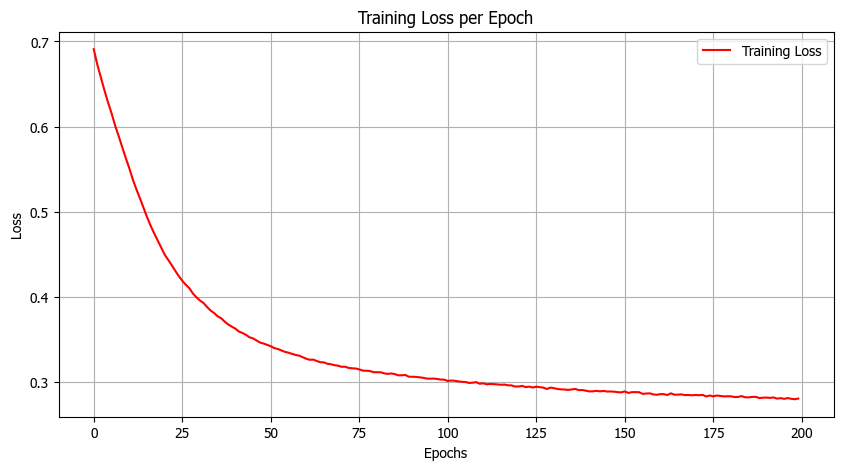

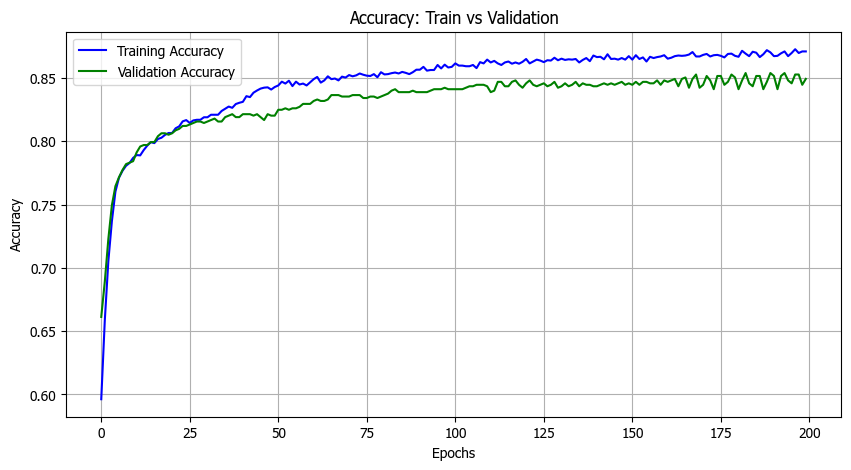

In [17]:


# ====================================================================
# 5. Train Model & Plotting (Fixed Version)
# ====================================================================
print("\n🔄 5. Training GCN...")
model_gnn = GCNNet(data.num_features, 2).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.001, weight_decay=5e-4)

# 🔥 ข้อมูล Balance แล้ว ไม่ต้องใช้ Class Weights
criterion = nn.CrossEntropyLoss()

# 📊 สร้างตัวแปรเก็บประวัติ
history = {
    'train_loss': [],
    'train_acc': [],
    'val_acc': []
}

best_val_acc = 0

for epoch in range(1, 201):
    model_gnn.train()
    optimizer.zero_grad()
    out = model_gnn(data)
    

    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    # ---  คำนวณ Training Accuracy ---
    with torch.no_grad():
        pred_train = out[data.train_mask].argmax(dim=1)
        train_correct = (pred_train == data.y[data.train_mask]).sum()
        train_acc = int(train_correct) / int(data.train_mask.sum())
        
        # เก็บค่าลง History
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)

    # --- Validation ---
    model_gnn.eval()
    with torch.no_grad():
        pred = model_gnn(data).argmax(dim=1)
        val_correct = (pred[data.val_mask] == data.y[data.val_mask]).sum()
        val_acc = int(val_correct) / int(data.val_mask.sum())
        
        # เก็บค่า Val Acc ลง History
        history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        #torch.save(model_gnn.state_dict(), 'best_model.pth')

    if epoch % 20 == 0:
        print(f"   Epoch {epoch:03d}: Loss {loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

print(f"\n✅ Training Complete! Best Val Acc: {best_val_acc:.4f}")

# ====================================================================
# 📊 Plot Graphs
# ====================================================================
print("📈 Plotting training history...")

# 1. กราฟ Loss
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss', color='red')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
#plt.savefig('graph_loss.png')
plt.show()

# 2. กราฟ Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Training Accuracy', color='blue')
plt.plot(history['val_acc'], label='Validation Accuracy', color='green')
plt.title('Accuracy: Train vs Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
#plt.savefig('graph_accuracy.png')
plt.show()

#print("✅ Saved graphs: graph_loss.png, graph_accuracy.png")

In [18]:
# # ====================================================================
# # 6. Save Artifacts (ใช้ข้อมูล x_balanced ที่เตรียมไว้ตอนแรก)
# # ====================================================================
# artifacts = {
#     'x_np': x_balanced,         # ✅ ใช้ข้อมูลเรียงวันที่
#     'y_cat_np': y_cat_balanced if 'y_cat_balanced' in globals() else None, 
#     'y_label_np': y_balanced,
#     'id2cat': id2cat if 'id2cat' in globals() else None,
#     'id2label': {0: 'ข่าวจริง', 1: 'ข่าวปลอม'},
#     'k': 10,
#     'model': model_gnn,
# }
# with open('artifacts.pkl', 'wb') as f:
#     pickle.dump(artifacts, f)
# print("✅ Saved 'artifacts.pkl' (Date-Balanced Version)")

In [19]:
def predict_news(
    content,
    topn=10,
    x_np=None,
    label2id=None,
    id2label=None,
    y_cat_np=None,
    id2cat=None,
    device=None,
    nbrs=None,
    model_gnn=None,
    embed_fn=None
):  
    # 0) Validate basics
    if embed_fn is None:
         raise ValueError("Missing 'embed_fn'. Please provide the embedding function.")
    
    # 1) Embedding: แปลงข้อความใหม่เป็น Vector
    # embed_fn ต้องคืนค่าเป็น list ของ numpy array หรือ tensor
    emb_batch = embed_fn([content])
    content_emb = emb_batch[0]
    
    # Normalize (L2) เพื่อให้เหมือนตอนเทรน และเหมาะกับ Cosine Similarity
    emb = normalize(content_emb.reshape(1, -1), axis=1, norm='l2')[0]

    # 2) KNN Search: หาข่าวเก่าที่คล้ายกัน
    # nbrs ต้องเป็นโมเดลที่ fit กับ x_np (Balanced) มาแล้ว
    dists, idxs = nbrs.kneighbors(emb.reshape(1, -1), n_neighbors=topn)
    idxs = idxs[0]
    
    # --- ส่วนทำนาย Category (Majority Vote) ---
    pred_category = "ไม่ระบุ"
    neighbor_cats = []
    
    if y_cat_np is not None and id2cat is not None:
        try:
            neighbor_cat_ids = y_cat_np[idxs]
            neighbor_cats = [id2cat[cid] for cid in neighbor_cat_ids]
            
            # โหวตหาหมวดหมู่ที่เจอบ่อยที่สุดในหมู่เพื่อนบ้าน
            most_common = Counter(neighbor_cats).most_common(1)
            if most_common:
                pred_category = most_common[0][0]
        except Exception as e:
            print(f"⚠️ Warning in Category Prediction: {e}")
            pass
    # ----------------------------------------

    # 3) Build Graph for GCN
    # สร้างกราฟดาว (Star Graph): ข่าวใหม่ (center=0) เชื่อมกับข่าวเก่า (neighbors=1..k)
    # ข้อมูล Node Feature: [ข่าวใหม่, เพื่อน1, เพื่อน2, ..., เพื่อนk]
    X_new = np.vstack([emb, x_np[idxs]])
    
    center = 0
    neighbors = np.arange(1, topn + 1)
    
    # สร้างเส้นเชื่อม (ไป-กลับ)
    # เส้นขาไป: 0 -> 1, 0 -> 2, ...
    # เส้นขากลับ: 1 -> 0, 2 -> 0, ...
    edge_index_new = np.concatenate([
        np.stack([np.full(topn, center), neighbors]),
        np.stack([neighbors, np.full(topn, center)])
    ], axis=1)
    
    # สร้างน้ำหนักเส้นเชื่อม (Weight) จากค่า Distance
    # ยิ่งใกล้ยิ่งค่ามาก (1 - dist)
    edge_weight_new = np.concatenate([1 - dists[0], 1 - dists[0]])

    # สร้าง Data Object สำหรับ PyTorch Geometric
    # ⚠️ ใช้ edge_attr เพื่อให้ตรงกับโครงสร้างโมเดลที่เทรนมา
    data_new = Data(
        x=torch.tensor(X_new, dtype=torch.float, device=device),
        edge_index=torch.tensor(edge_index_new, dtype=torch.long, device=device),
        edge_attr=torch.tensor(edge_weight_new, dtype=torch.float, device=device), 
    )

    # 4) Predict Real/Fake
    model_gnn.eval()
    with torch.no_grad():
        logits = model_gnn(data_new)
        
        # เอาผลลัพธ์ของ Node ที่ 0 (ข่าวใหม่)
        probas = torch.softmax(logits, dim=1)[0].cpu().numpy()
        
        pred_id = int(np.argmax(probas)) 
        label_pred = id2label[pred_id]

    return {
        'label': label_pred,           # ผลทำนาย: ข่าวจริง/ปลอม
        'probability': float(probas[pred_id]), # ความมั่นใจ (0.0 - 1.0)
        'proba_all': probas.tolist(),  # ค่าความน่าจะเป็นของทั้ง 2 คลาส
        'category': pred_category,     # ผลทำนาย: หมวดหมู่
        'neighbor_cats': neighbor_cats, # หมวดหมู่ของข่าวที่คล้ายกัน
        'pred_id': pred_id               # ตัวเลขคลาสที่ทำนาย
    }

In [ ]:
warnings.filterwarnings("ignore", message=".*encoder_attention_mask.*")
warnings.filterwarnings("ignore", message=".*CamembertSdpaSelfAttention.*")
# ====================================================================
# PART 1 — Evaluate GCN on Test set
# ====================================================================
model_gnn.eval()
with torch.no_grad():
    final_out_gcn = model_gnn(data_st)   # ✅ แก้: data → data_st

    y_true_gcn = data_st.y[data_st.test_mask].cpu().numpy()   # ✅ แก้
    y_pred_gcn = final_out_gcn[data_st.test_mask].argmax(dim=1).cpu().numpy()  # ✅ แก้

acc       = accuracy_score(y_true_gcn, y_pred_gcn)
precision = precision_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
recall    = recall_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
f1        = f1_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)

results_gcn = {
    "Accuracy": float(acc),
    "Precision_weighted": float(precision),
    "Recall_weighted": float(recall),
    "F1_weighted": float(f1),
}

print("-" * 60)
print("GCN Test Evaluation (Spatio-Temporal Graph)")  # ✅ แก้ข้อความ
print("-" * 60)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("-" * 60)
print("\nDetailed Classification Report:")
print(classification_report(y_true_gcn, y_pred_gcn, digits=4))

------------------------------------------------------------
GCN Test Evaluation (from Test Mask)
------------------------------------------------------------
Accuracy:  0.8654
Precision: 0.8683
Recall:    0.8654
F1-score:  0.8652
------------------------------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.9008    0.8213    0.8592       431
           1     0.8358    0.9095    0.8711       431

    accuracy                         0.8654       862
   macro avg     0.8683    0.8654    0.8652       862
weighted avg     0.8683    0.8654    0.8652       862

------------------------------------------------------------


In [21]:
# 📌  สร้างชุดข้อมูลทดสอบใหม่ (Test Set) 20 ข่าว
# 'label_true': 0 = ข่าวจริง, 1 = ข่าวปลอม (ตาม label2id: {'ข่าวจริง': 0, 'ข่าวปลอม': 1})
test_news_data = [
    # --- ข่าวจริง 10 ตัวอย่าง (Label 0) ---
    {"content": "ททท. เปิดตัว “ลิซ่า” เป็นตัวแทนการท่องเที่ยวไทย Amazing Thailand Ambassador","label_true": 0},
    {"content": "สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล' หลังพังถล่มจากฝนตกหนัก", "label_true": 0},
    {"content": "บขส. เปิดให้บริการเดินรถโดยสาร เส้นทาง ขอนแก่น – นครหลวงเวียงจันทน์", "label_true": 0},
    {"content": "อุทยานฯ เขาพนมเบญจา ชวนนักท่องเที่ยว ตามรอยจูราสสิค เวิลด์ กำเนิดชีวิตใหม่ น้ำตกห้วยโต้", "label_true": 0},
    {"content": "พบอิฐโบราณชิ้นสำคัญ หลักฐานทางประวัติศาสตร์ที่เก่าแก่ของเชียงราย", "label_true": 0},
    {"content": "ปิดเทอม สวนสัตว์เปิดเขาเขียว เผยโฉม 'ลูกสมเสร็จตัวล่าสุด' เด็กเที่ยวฟรี 23 ตุลาคมนี้", "label_true": 0},
    {"content": "อาการเจ็บหน้าอก สัญญาณอันตรายที่ไม่ควรมองข้าม","label_true": 0},
    {"content": "กกล.บูรพา จับกุมแรงงานกัมพูชา 11 คน ลักลอบข้ามชายแดนสระแก้ว","label_true": 0},
    {"content": "ททท.คาด 'เทศกาลกินผักภูเก็ต 2568' คึกคัก รายได้ทะลุ 22,000 ล้านบาท หนุนเศรษฐกิจสะพัด", "label_true": 0},
    {"content": "“ข้าวต้ม” ฟื้นตัวดี ถีบตัวลุกได้ ทีมแพทย์ช่วยกายภาพต่อเนื่อง", "label_true": 0},
    
    # --- ข่าวปลอม 10 ตัวอย่าง (Label 1) ---
    {"content": "ด่วน! สะพานกรุงเทพถล่ม มีผู้เสียชีวิต 36 ราย", "label_true": 1},
    {"content": "กระทรวงยุติธรรม ร่วมกับ ตำรวจไซเบอร์ เปิดให้ลงทะเบียนยื่นหลักฐาน เพื่อรับเงินคืนจากมิจฉาชีพ", "label_true": 1},
    {"content": "การดื่มน้ำมะนาวสามารถทำลายมะเร็งเนื้อร้ายที่รุนแรงได้", "label_true": 1},
    {"content": "ผู้สูงอายุ 60 ปีขึ้นไป รับเงินอุดหนุนพิเศษ 3,000 บาท ไม่ต้องลงทะเบียน", "label_true": 1},
    {"content": "กรมการขนส่งเปิดทำใบขับขี่ออนไลน์ ผ่านเพจเฟซบุ๊ก Pages DTL Noline", "label_true": 1},
    {"content": "กินถั่วลิสงวันละ 1 กำมือ ช่วยรักษาอาการวัยทอง อารมณ์แปรปรวน","label_true": 1},
    {"content": "กฟภ. เปิดช่องทางติดต่อด่วน ทางไลน์ไอดี 'pea9394'", "label_true": 1},
    {"content": "สินเชื่อด่วนออมสิน สมัครง่าย ไม่ต้องใช้เอกสาร ติดต่อได้ที่เพจ Ulises Elizabeth Love", "label_true": 1},
    {"content": "รองแม่ทัพภาคที่ 2 ถูกตำหนิ เหตุรับเงินบริจาควัด", "label_true": 1},
    {"content": "วางก้อนน้ำแข็งบนท้ายทอย ช่วยรักษาโรคทางเดินหายใจ โรคหลอดเลือดหัวใจ และอาการปวดเมื่อยตามร่างกาย", "label_true": 1}
]

In [22]:
# ✅ ปิดคำเตือน FutureWarning ที่น่ารำคาญจาก Transformers (ปิดแบบเข้มงวด)
# ดักจับข้อความที่มีคำว่า encoder_attention_mask แบบครอบคลุม
warnings.filterwarnings("ignore", message=".*encoder_attention_mask.*")
# ดักจับเฉพาะเจาะจงสำหรับ CamembertSdpaSelfAttention ที่โผล่มาบ่อยๆ
warnings.filterwarnings("ignore", message=".*CamembertSdpaSelfAttention.*")

# ====================================================================
# PART 2 — Predict multiple new news samples (With Category)
# ====================================================================

#  Fit KNN ใหม่ด้วยข้อมูลชุดที่เลือกมา
print(f"🔄 Re-fitting KNN with data size: {len(x_balanced)}...")
current_nbrs = NearestNeighbors(n_neighbors=k, metric='cosine').fit(x_balanced)

# สร้าง id2label จาก label2id ที่มีอยู่
id2label = {i: c for c, i in label2id.items()}

# เก็บค่าจริงและค่าทำนาย (สำหรับ Real/Fake)
y_true = []
y_pred = []

print("-" * 80)
print(f"--- Running Prediction on {len(test_news_data)} News Samples ---")
print("-" * 80)

# สร้างฟังก์ชันฝังตัวแปร (Wrapper)
my_embed_fn = lambda texts: get_bert_embeddings_batch(
    texts,
    tokenizer=tokenizer,
    model=lm_model,
    device=device
)

for i, news in enumerate(test_news_data):
    try:
        # เรียกใช้ฟังก์ชัน
        result = predict_news(
            content=news['content'],
            x_np=x_balanced,       # ✅ ใช้ข้อมูลที่เลือกมา (Auto-select)
            nbrs=current_nbrs,    # ✅ ใช้ KNN ตัวใหม่
            label2id=label2id,
            id2label=id2label,
            y_cat_np=y_cat_balanced if 'y_cat_balanced' in globals() else y_cat_np, 
            id2cat=id2cat,      
            device=device,
            topn=k,
            model_gnn=model_gnn,
            embed_fn=my_embed_fn
        )

        # -----------------------------------------------------------
        # ดึง ID มาใช้ได้เลย
        # -----------------------------------------------------------
        pred_id = result['pred_id']

        y_true.append(news["label_true"])
        y_pred.append(pred_id)

        # เช็คความถูกต้อง (เฉพาะ Real/Fake)
        status = "✅" if pred_id == news["label_true"] else "❌"
        
        # 📌📌 ส่วนที่เพิ่ม: แสดงผลละเอียดเพื่อ Debug 📌📌
        print(f"[{status}] News: {news['content'][:50]}...") # ตัดข้อความสั้นๆ
        print(f"    TRUE: {id2label[news['label_true']]} | PRED: {result['label']} | Prob: {result['probability']:.3f}")
        print(f"    -> หมวดหมู่ข่าวนี้: {result['category']}")
        print(f"    -> เพื่อนบ้านที่เจอ ({k} คน): {result['neighbor_cats']}") 
        print("-" * 50)
    
    except Exception as e:
        print(f"Error predicting sample {i}: {e}")

# =====================================================================
# CONFUSION MATRIX & METRICS (เฉพาะ Real/Fake)
# =====================================================================
if len(y_pred) > 0:
    print("\n" + "="*60)
    print(" SUMMARY REPORT ")
    print("="*60)
    
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    # ถ้าอยากปริ้นท์สวยๆ
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        print(f"True Neg (0): {tn} | False Pos (0->1): {fp}")
        print(f"False Neg (1->0): {fn} | True Pos (1): {tp}")

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print("-" * 30)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("-" * 30)

    print("\nClassification Report:")
    # ตรวจสอบว่า Class 0 คืออะไร Class 1 คืออะไร ให้ชัวร์
    print(classification_report(
        y_true,
        y_pred,
        target_names=[id2label[0], id2label[1]], 
        zero_division=0
    ))

🔄 Re-fitting KNN with data size: 5744...
--------------------------------------------------------------------------------
--- Running Prediction on 20 News Samples ---
--------------------------------------------------------------------------------
[✅] News: ททท. เปิดตัว “ลิซ่า” เป็นตัวแทนการท่องเที่ยวไทย Am...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.608
    -> หมวดหมู่ข่าวนี้: นโยบายรัฐบาล-ข่าวสาร
    -> เพื่อนบ้านที่เจอ (10 คน): ['นโยบายรัฐบาล-ข่าวสาร', 'นโยบายรัฐบาล-ข่าวสาร', 'นโยบายรัฐบาล-ข่าวสาร', 'นโยบายรัฐบาล-ข่าวสาร', 'การเงิน-หุ้น', 'การเงิน-หุ้น', 'นโยบายรัฐบาล-ข่าวสาร', 'นโยบายรัฐบาล-ข่าวสาร', 'นโยบายรัฐบาล-ข่าวสาร', 'นโยบายรัฐบาล-ข่าวสาร']
--------------------------------------------------
[✅] News: สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล'...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.958
    -> หมวดหมู่ข่าวนี้: ภัยพิบัติ
    -> เพื่อนบ้านที่เจอ (10 คน): ['ภัยพิบัติ', 'ภัยพิบัติ', 'ความสงบและความมั่นคง', 'ภัยพิบัติ', 'ภัยพิบัติ', 'นโยบายรัฐบาล-ข่าวสาร', '

In [23]:
# ====================================================================
# PART 3 — Baseline Models Comparison (อัปเดตโมเดลตามยุคสมัย)
# ====================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pythainlp.tokenize import word_tokenize
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("🚀 STARTING BASELINE MODELS COMPARISON")
print("="*80)

# เตรียมข้อมูล
texts_balanced = df.iloc[idx_balanced]['หัวข้อข่าว'].astype(str).tolist()
y_train_base = y_balanced[idx_train]
y_test_base = y_balanced[idx_test]

results_comparison = {}
# ดึงผลลัพธ์ของ GCN ที่ทำไว้แล้วมาเก็บรอไว้
results_comparison['1. GCN (Wangchan+Graph)'] = results_gcn  

# ---------------------------------------------------------
# Baseline 1: TF-IDF + Logistic Regression (ยุคเก่า)
# ---------------------------------------------------------
print("\nTraining Baseline 1: TF-IDF + Logistic Regression...")
def thai_tokenizer(text):
    return word_tokenize(text, engine='newmm', keep_whitespace=False)

tfidf = TfidfVectorizer(tokenizer=thai_tokenizer, max_features=5000)
train_texts = [texts_balanced[i] for i in idx_train]
test_texts = [texts_balanced[i] for i in idx_test]

X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf = tfidf.transform(test_texts)

clf_tfidf = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train_base)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

results_comparison['2. TF-IDF + LR'] = {
    "Accuracy": accuracy_score(y_test_base, y_pred_tfidf),
    "Precision_weighted": precision_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    "Recall_weighted": recall_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    "F1_weighted": f1_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0)
}

# ---------------------------------------------------------
# Baseline 2: WangchanBERTa + Random Forest (ยุคกลาง)
# ---------------------------------------------------------
print("\nTraining Baseline 2: WangchanBERTa + Random Forest...")
X_train_wcb = x_balanced[idx_train]
X_test_wcb = x_balanced[idx_test]

clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_train_wcb, y_train_base)
y_pred_wcb_rf = clf_rf.predict(X_test_wcb)

results_comparison['3. WangchanBERTa + RF'] = {
    "Accuracy": accuracy_score(y_test_base, y_pred_wcb_rf),
    "Precision_weighted": precision_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
    "Recall_weighted": recall_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
    "F1_weighted": f1_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0)
}

# ---------------------------------------------------------
# Baseline 3: XLM-RoBERTa + Logistic Regression (Multilingual)
# ---------------------------------------------------------
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import normalize
import torch

print("\nTraining Baseline 3: XLM-RoBERTa + Logistic Regression...")

# 1. โหลด Model & Tokenizer ของ XLM-R
model_xlm_name = "xlm-roberta-base"
tokenizer_xlm = AutoTokenizer.from_pretrained(model_xlm_name)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_xlm = AutoModel.from_pretrained(model_xlm_name).to(device).eval()

# 2. Extract Embeddings (ดึงฟีเจอร์จากข้อความ)
print(" -> Extracting XLM-RoBERTa embeddings (this might take a moment)...")
xlm_emb = get_bert_embeddings_batch(
    texts_balanced,
    tokenizer=tokenizer_xlm,
    model=model_xlm,
    device=device,
    max_length=256,
    batch_size=32,
    use_mean_pool=True
)

# 3. Normalize (L2) ให้มาตรฐานเดียวกับ WangchanBERTa
xlm_emb_norm = normalize(xlm_emb, axis=1, norm='l2')

# 4. แบ่ง Train/Test สำหรับ XLM-RoBERTa
X_train_xlm = xlm_emb_norm[idx_train]
X_test_xlm = xlm_emb_norm[idx_test]

# 5. เทรนโมเดล Logistic Regression
clf_xlm = LogisticRegression(max_iter=1000, random_state=42)
clf_xlm.fit(X_train_xlm, y_train_base)
y_pred_xlm = clf_xlm.predict(X_test_xlm)

# 6. เก็บผลลัพธ์
results_comparison['4. XLM-RoBERTa + LR'] = {
    "Accuracy": accuracy_score(y_test_base, y_pred_xlm),
    "Precision_weighted": precision_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    "Recall_weighted": recall_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    "F1_weighted": f1_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0)
}
print("✅ Baseline 3 Trained Successfully!")


🚀 STARTING BASELINE MODELS COMPARISON

Training Baseline 1: TF-IDF + Logistic Regression...


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



Training Baseline 2: WangchanBERTa + Random Forest...

Training Baseline 3: XLM-RoBERTa + Logistic Regression...
 -> Extracting XLM-RoBERTa embeddings (this might take a moment)...
✅ Baseline 3 Trained Successfully!



📊 MODEL COMPARISON RESULTS (สรุปผลการเปรียบเทียบ)
                         Accuracy  Precision_weighted  Recall_weighted  \
1. GCN (Wangchan+Graph)    0.8654              0.8683           0.8654   
2. TF-IDF + LR             0.9072              0.9083           0.9072   
3. WangchanBERTa + RF      0.8480              0.8501           0.8480   
4. XLM-RoBERTa + LR        0.8527              0.8527           0.8527   

                         F1_weighted  
1. GCN (Wangchan+Graph)       0.8652  
2. TF-IDF + LR                0.9071  
3. WangchanBERTa + RF         0.8478  
4. XLM-RoBERTa + LR           0.8527  
--------------------------------------------------------------------------------


<Figure size 1400x700 with 0 Axes>

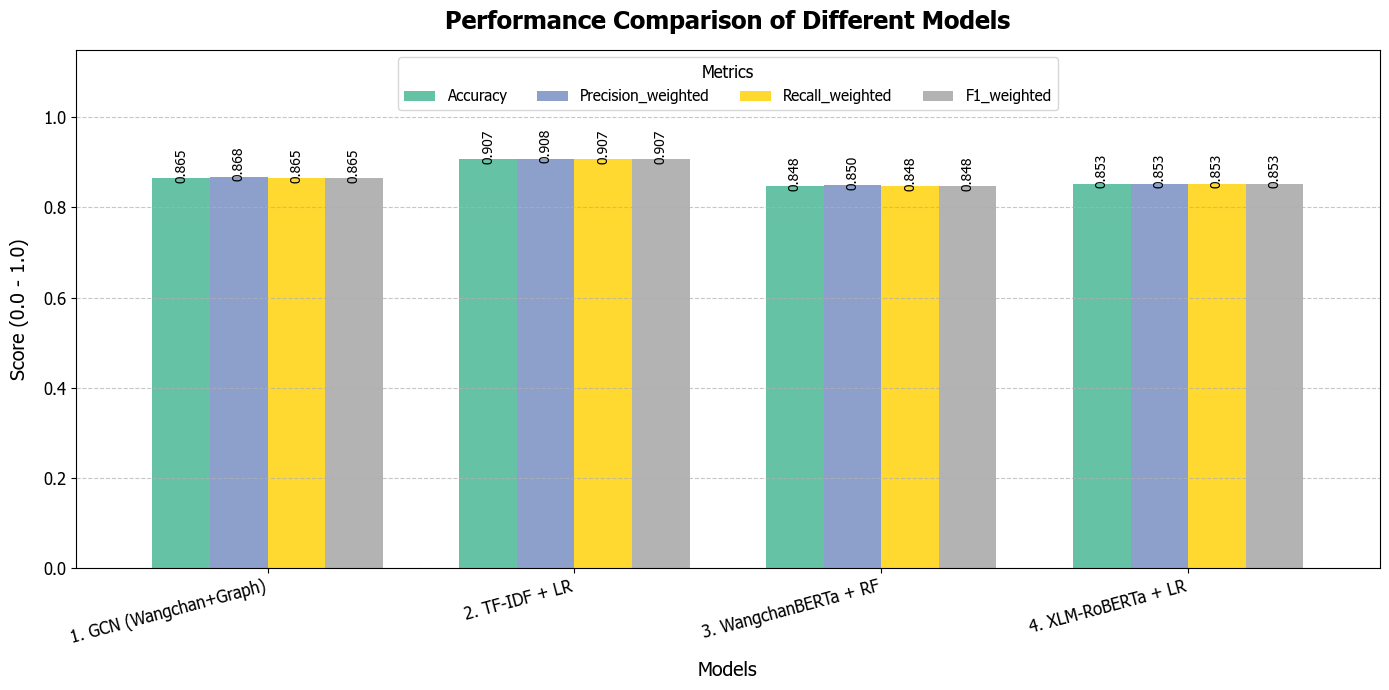


✅ แสดงผลตารางและกราฟเปรียบเทียบสำเร็จ!


In [24]:
# ====================================================================
# 📊 ตารางสรุปผลและกราฟเปรียบเทียบประสิทธิภาพโมเดล
# ====================================================================
import seaborn as sns

print("\n" + "="*80)
print("📊 MODEL COMPARISON RESULTS (สรุปผลการเปรียบเทียบ)")
print("="*80)

# 1. นำข้อมูลใน Dictionary มาแปลงเป็นตาราง (DataFrame) เพื่อง่ายต่อการดู
df_results = pd.DataFrame(results_comparison).T
df_results = df_results[['Accuracy', 'Precision_weighted', 'Recall_weighted', 'F1_weighted']] # จัดเรียงคอลัมน์

# ปริ้นท์ตารางออกมาดูแบบทศนิยม 4 ตำแหน่ง
print(df_results.round(4))
print("-" * 80)

# 2. วาดกราฟเปรียบเทียบ (Bar Chart)
plt.figure(figsize=(14, 7))

# ใช้ Pandas plot สร้างกราฟแท่งแบบกลุ่ม
ax = df_results.plot(
    kind='bar', 
    figsize=(14, 7), 
    colormap='Set2',  # ชุดสีที่ดูสบายตาและแยกชัดเจน
    width=0.75
)

plt.title('Performance Comparison of Different Models', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Models', fontsize=14, labelpad=10)
plt.ylabel('Score (0.0 - 1.0)', fontsize=14, labelpad=10)

# ขยายแกน Y ให้ทะลุ 1.0 ไปนิดนึง เพื่อให้มีที่ว่างวาง Legend
plt.ylim(0, 1.15) 
plt.xticks(rotation=15, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# จัดการตัว Legend (คำอธิบายสี) ให้อยู่ด้านบน
plt.legend(title='Metrics', title_fontsize='12', fontsize='11', loc='upper center', ncol=4)

# ใส่เส้นตารางแนวนอนให้อ่านกราฟง่ายขึ้น
plt.grid(axis='y', linestyle='--', alpha=0.7)

# (Optional) ใส่ตัวเลขกำกับบนแท่งกราฟเฉพาะค่า Accuracy เพื่อความเป๊ะ
for p in ax.patches:
    # กรองแสดงเฉพาะแท่งที่เกี่ยวข้องกับค่า Accuracy (ตัวอย่างการปรับแต่งเบื้องต้น)
    # ในที่นี้เราจะแสดงค่าตัวเลขบนทุกแท่งให้เห็นชัดเจน
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, rotation=90) # หมุนตัวเลข 90 องศาเพื่อไม่ให้ทับกัน

plt.tight_layout()

# เซฟรูปลงเครื่อง เผื่อเอาไปแปะในรายงาน
# plt.savefig('model_comparison_chart.png', dpi=300) 

plt.show()

print("\n✅ แสดงผลตารางและกราฟเปรียบเทียบสำเร็จ!")


🔍 GENERATING CONFUSION MATRICES FOR ALL MODELS


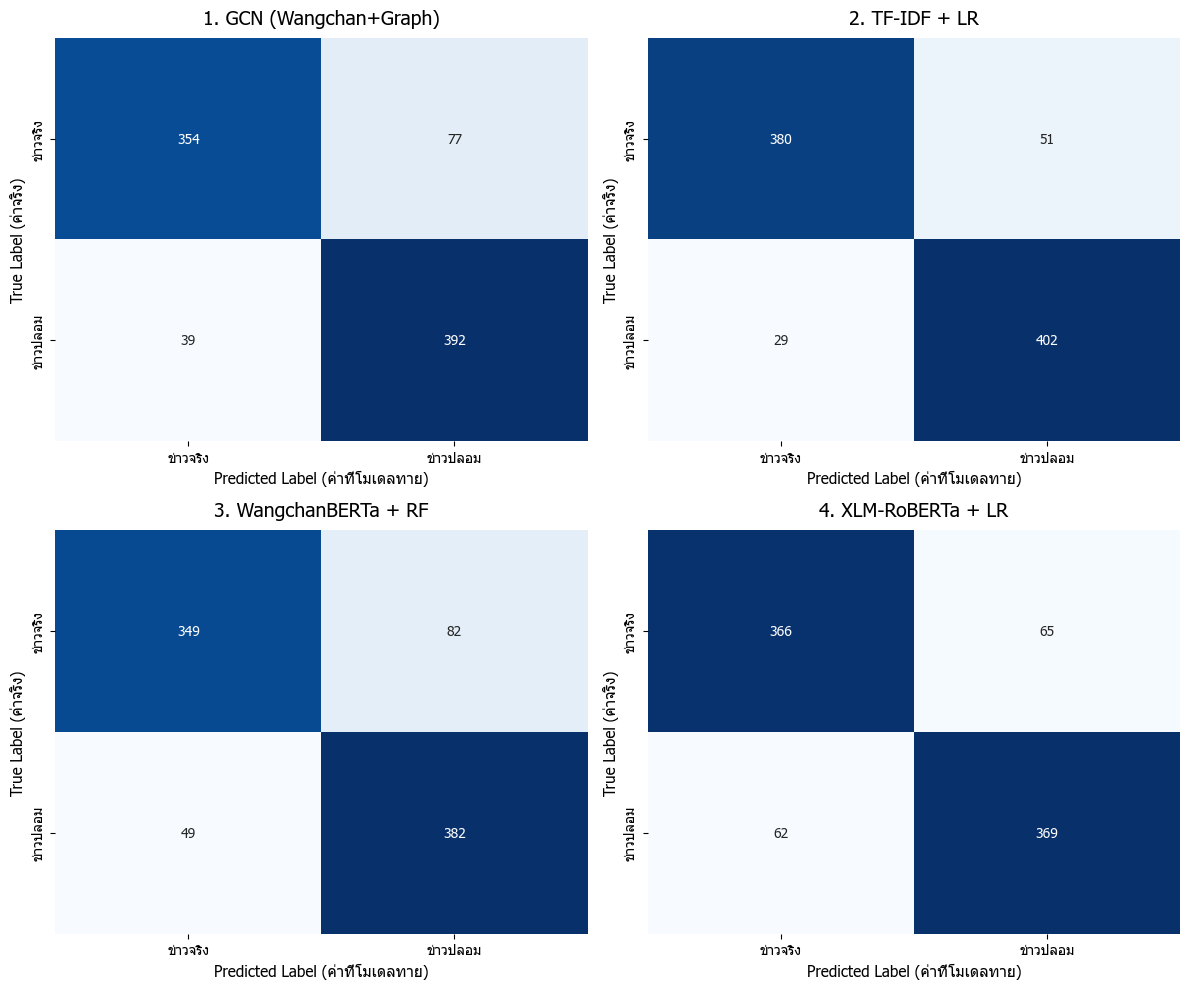

In [25]:
# ====================================================================
# PART 4 — Confusion Matrices Comparison (All Models)
# ====================================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n" + "="*80)
print("🔍 GENERATING CONFUSION MATRICES FOR ALL MODELS")
print("="*80)

class_names = [id2label[0], id2label[1]]

# แมปชื่อและผลลัพธ์ให้ตรงกับที่เทรนมาใหม่
model_predictions = [
    ("1. GCN (Wangchan+Graph)", y_true_gcn, y_pred_gcn),
    ("2. TF-IDF + LR", y_test_base, y_pred_tfidf),
    ("3. WangchanBERTa + RF", y_test_base, y_pred_wcb_rf),
    ("4. XLM-RoBERTa + LR", y_test_base, y_pred_xlm)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (model_name, y_true_model, y_pred_model) in enumerate(model_predictions):
    cm = confusion_matrix(y_true_model, y_pred_model)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', 
        ax=axes[i], xticklabels=class_names, yticklabels=class_names, cbar=False
    )
    axes[i].set_title(model_name, fontsize=14, pad=10)
    axes[i].set_xlabel('Predicted Label (ค่าที่โมเดลทาย)', fontsize=11)
    axes[i].set_ylabel('True Label (ค่าจริง)', fontsize=11)

plt.tight_layout()
plt.show()

In [26]:
# ====================================================================
# PART 5 — Error Analysis: ดึงข่าวที่โมเดล GCN ทายผิดพลาด
# ====================================================================
print("\n" + "="*80)
print("🚨 ERROR ANALYSIS: ข่าวที่โมเดล GCN ทายผิดพลาด (Test Set)")
print("="*80)

# 1. ดึง index ของข้อมูลที่เป็น Test set (อิงจาก mask ที่เราสร้างไว้)
test_indices = np.where(data.test_mask.cpu().numpy())[0]

# 2. ดึงข้อความข่าวเฉพาะในชุด Test set 
# (texts_balanced ถูกสร้างไว้ตอนรันโมเดล Baseline)
texts_test = [texts_balanced[i] for i in test_indices]

# 3. รวบรวมข่าวที่ทายผิด
misclassified_samples = []
for i in range(len(y_true_gcn)):
    true_label = y_true_gcn[i]
    pred_label = y_pred_gcn[i]
    
    # ถ้าค่าจริง ไม่ตรงกับ ค่าที่ทำนาย -> แปลว่าทายผิด
    if true_label != pred_label:
        error_type = "False Positive (หลงผิดคิดว่าปลอม)" if pred_label == 1 else "False Negative (โดนหลอกคิดว่าจริง)"
        
        misclassified_samples.append({
            'text': texts_test[i],
            'true_label_text': id2label[true_label],
            'pred_label_text': id2label[pred_label],
            'error_type': error_type
        })

# 4. แสดงผลลัพธ์ (จำกัดที่ 20 ข่าว)
num_to_show = 20
total_errors = len(misclassified_samples)

print(f"พบข่าวที่ทายผิดทั้งหมด {total_errors} ข่าว (จาก {len(y_true_gcn)} ข่าวในชุดทดสอบ)")
print(f"กำลังแสดงตัวอย่าง {min(num_to_show, total_errors)} ข่าวแรก:\n")

for idx, item in enumerate(misclassified_samples[:num_to_show]):
    print(f"[{idx+1}] ❌ {item['error_type']}")
    print(f"เนื้อหาข่าว : {item['text']}")
    print(f"ค่าจริง (True) : {item['true_label_text']} | ทำนาย (Pred) : {item['pred_label_text']}")
    print("-" * 70)

# (Optional) หากต้องการบันทึกข่าวที่ทายผิดทั้งหมดลง CSV เพื่อเอาไปวิเคราะห์ต่อใน Excel
# df_errors = pd.DataFrame(misclassified_samples)
# df_errors.to_csv('misclassified_news_gcn.csv', index=False, encoding='utf-8-sig')
# print("\n✅ บันทึกข่าวที่ทายผิดทั้งหมดลงไฟล์ 'misclassified_news_gcn.csv' เรียบร้อยแล้ว")


🚨 ERROR ANALYSIS: ข่าวที่โมเดล GCN ทายผิดพลาด (Test Set)
พบข่าวที่ทายผิดทั้งหมด 116 ข่าว (จาก 862 ข่าวในชุดทดสอบ)
กำลังแสดงตัวอย่าง 20 ข่าวแรก:

[1] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหาข่าว : อายุครบ 55 ปี ส่งเงินสมทบครบ 180 เดือน รับเงินบำนาญชราภาพรายเดือนตลอดชีวิต
ค่าจริง (True) : ข่าวจริง | ทำนาย (Pred) : ข่าวปลอม
----------------------------------------------------------------------
[2] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหาข่าว : CMAC เตือนประชาชนและผู้ลี้ภัย ระมัดระวังวัตถุระเบิดตกค้างในบางพื้นที่
ค่าจริง (True) : ข่าวจริง | ทำนาย (Pred) : ข่าวปลอม
----------------------------------------------------------------------
[3] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหาข่าว : 29 ธ.ค. ทหารไทยเหยียบทุ่นระเบิด ขณะปฏิบัติหน้าที่บริเวณเขาสัตตะโสม
ค่าจริง (True) : ข่าวจริง | ทำนาย (Pred) : ข่าวปลอม
----------------------------------------------------------------------
[4] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหาข่าว : กองทัพขอความร่วมมือประชาชน ห้ามเก็บ ครอบครอง หรือเคลื่อนย


📊 KEYWORD ANALYSIS: คำศัพท์ที่มักทำให้โมเดลทายผิด
📌 Top 15 คำในข่าวที่โมเดล 'หลงผิดคิดว่าปลอม' (False Positive / ความจริงคือข่าวจริง):
   - ไทย: 11 ครั้ง
   - พื้นที่: 7 ครั้ง
   - กัมพูชา: 7 ครั้ง
   - โรค: 7 ครั้ง
   - อาการ: 5 ครั้ง
   - เตือน: 4 ครั้ง
   - ประชาชน: 4 ครั้ง
   - บาท: 4 ครั้ง
   - จีน: 4 ครั้ง
   - เงิน: 4 ครั้ง
   - เสี่ยง: 4 ครั้ง
   - ทหาร: 3 ครั้ง
   - ตรวจ: 3 ครั้ง
   - เกษตรกร: 3 ครั้ง
   - มะเร็ง: 3 ครั้ง

📌 Top 15 คำในข่าวที่โมเดล 'โดนหลอกคิดว่าจริง' (False Negative / ความจริงคือข่าวปลอม):
   - ไทย: 7 ครั้ง
   - วันที่: 4 ครั้ง
   - 68: 4 ครั้ง
   - สินค้า: 4 ครั้ง
   - เรือ: 3 ครั้ง
   - จ.: 3 ครั้ง
   - แจ้ง: 3 ครั้ง
   - เตือน: 3 ครั้ง
   - แผ่นดินไหว: 3 ครั้ง
   - ประเทศ: 3 ครั้ง
   - สะพาน: 3 ครั้ง
   - ปี: 3 ครั้ง
   - รถไฟ: 2 ครั้ง
   - พิเศษ: 2 ครั้ง
   - เชียงใหม่: 2 ครั้ง


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_20840\2299393337.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_fp), y=list(words_fp), ax=axes[0], palette='Reds_r')
C:\Users\tt_pe\AppData\Local\Temp\ipykernel_20840\2299393337.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_fn), y=list(words_fn), ax=axes[1], palette='Oranges_r')


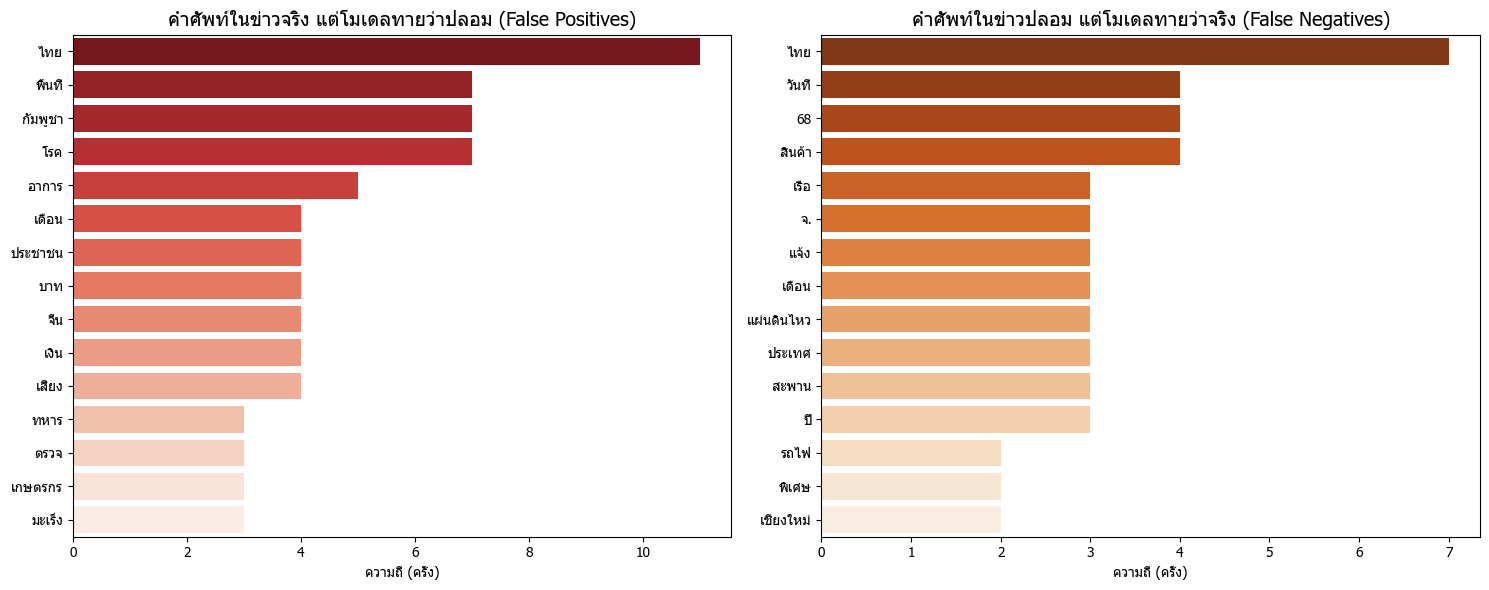


✅ บันทึกกราฟคำศัพท์ที่ผิดพลาดลงไฟล์ 'graph_error_keywords.png' เรียบร้อยแล้ว


In [27]:
# ====================================================================
# PART 6 — Keyword Analysis for Misclassified News (สถิติคำที่ทำโมเดลสับสน)
# ====================================================================
from pythainlp.corpus import thai_stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("📊 KEYWORD ANALYSIS: คำศัพท์ที่มักทำให้โมเดลทายผิด")
print("="*80)

# 1. โหลด Stopwords ภาษาไทย และเพิ่มคำที่ไม่อยากให้นับ (Custom Stopwords)
stopwords = set(thai_stopwords())
custom_stopwords = {' ', '\n', '(', ')', '"', "'", '!', '?', '-', '”', '“', ':', '/', 'ๆ', 
                    'ได้', 'ที่', 'ใน', 'การ', 'และ', 'เป็น', 'มี', 'ให้', 'ของ', 'จะ', 'ว่า'}
all_stopwords = stopwords.union(custom_stopwords)

# ฟังก์ชันสำหรับสกัดและนับคำศัพท์จาก List ของข่าว
def get_top_keywords(news_list, top_n=15):
    all_words = []
    for item in news_list:
        text = str(item['text'])
        # ตัดคำด้วย newmm
        words = word_tokenize(text, engine='newmm', keep_whitespace=False)
        # กรองคำที่เป็น stopword และคำที่สั้นเกินไป (ยาว < 2)
        filtered_words = [w for w in words if w not in all_stopwords and len(w) > 1]
        all_words.extend(filtered_words)
    
    # นับความถี่และคืนค่าคำที่เจอบ่อยสุด
    return Counter(all_words).most_common(top_n)

# 2. แยกกลุ่มข่าวที่ทายผิด (จากตัวแปร misclassified_samples ใน Part 5)
fp_news = [item for item in misclassified_samples if "False Positive" in item['error_type']]
fn_news = [item for item in misclassified_samples if "False Negative" in item['error_type']]

# ดึง Top 15 Keywords
top_fp_words = get_top_keywords(fp_news, top_n=15)
top_fn_words = get_top_keywords(fn_news, top_n=15)

# 3. พิมพ์ผลลัพธ์ออกทางหน้าจอ
print(f"📌 Top 15 คำในข่าวที่โมเดล 'หลงผิดคิดว่าปลอม' (False Positive / ความจริงคือข่าวจริง):")
for word, count in top_fp_words:
    print(f"   - {word}: {count} ครั้ง")

print(f"\n📌 Top 15 คำในข่าวที่โมเดล 'โดนหลอกคิดว่าจริง' (False Negative / ความจริงคือข่าวปลอม):")
for word, count in top_fn_words:
    print(f"   - {word}: {count} ครั้ง")

# 4. พลอตกราฟเปรียบเทียบ (Bar Chart)
if len(top_fp_words) > 0 and len(top_fn_words) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # พลอตฝั่ง False Positive (สีแดง)
    words_fp, counts_fp = zip(*top_fp_words)
    sns.barplot(x=list(counts_fp), y=list(words_fp), ax=axes[0], palette='Reds_r')
    axes[0].set_title('คำศัพท์ในข่าวจริง แต่โมเดลทายว่าปลอม (False Positives)', fontsize=14)
    axes[0].set_xlabel('ความถี่ (ครั้ง)')
    
    # พลอตฝั่ง False Negative (สีส้ม)
    words_fn, counts_fn = zip(*top_fn_words)
    sns.barplot(x=list(counts_fn), y=list(words_fn), ax=axes[1], palette='Oranges_r')
    axes[1].set_title('คำศัพท์ในข่าวปลอม แต่โมเดลทายว่าจริง (False Negatives)', fontsize=14)
    axes[1].set_xlabel('ความถี่ (ครั้ง)')
    
    plt.tight_layout()
    #plt.savefig('graph_error_keywords.png', dpi=300)
    plt.show()
    print("\n✅ บันทึกกราฟคำศัพท์ที่ผิดพลาดลงไฟล์ 'graph_error_keywords.png' เรียบร้อยแล้ว")
else:
    print("\n⚠️ ไม่พบข้อมูลคำศัพท์เพียงพอที่จะพลอตกราฟ (โมเดลอาจจะทายถูกเกือบหมด!)")

In [28]:
# ====================================================================
# PART 7 — Cross-Model Error Analysis (วิเคราะห์จุดอ่อนของทั้ง 4 โมเดล)
# ====================================================================
import pandas as pd
import numpy as np

print("\n" + "="*80)
print("🕵️‍♂️ CROSS-MODEL ERROR ANALYSIS: ค้นหา 'ข่าวปราบเซียน' ที่หลอกได้ทุกโมเดล")
print("="*80)

# 1. สร้าง DataFrame รวบรวมผลทายของทุกโมเดลใน Test Set
# อิงจากตัวแปรที่เรามีในโค้ดก่อนหน้า
df_errors_all = pd.DataFrame({
    'text': test_texts,           # ใช้ test_texts ที่ดึงไว้จาก PART 3
    'true_label': y_test_base,
    'pred_gcn': y_pred_gcn,
    'pred_wcb': y_pred_wcb_rf,    # ✅ แก้ชื่อตัวแปรตรงนี้เป็น y_pred_wcb_rf (Random Forest)
    'pred_xlm': y_pred_xlm,
    'pred_tfidf': y_pred_tfidf
})

# แปลง Label ตัวเลขเป็นข้อความให้ดูง่าย
df_errors_all['true_label_text'] = df_errors_all['true_label'].map({0: id2label[0], 1: id2label[1]})

# 2. เช็คว่าแต่ละโมเดลทายผิดหรือไม่ (True = ทายผิด, False = ทายถูก)
df_errors_all['gcn_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_gcn']
df_errors_all['wcb_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_wcb']
df_errors_all['xlm_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_xlm']
df_errors_all['tfidf_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_tfidf']

# นับจำนวนโมเดลที่ทายผิดในข่าวนั้นๆ (0 ถึง 4)
df_errors_all['num_models_wrong'] = (
    df_errors_all['gcn_wrong'].astype(int) + 
    df_errors_all['wcb_wrong'].astype(int) + 
    df_errors_all['xlm_wrong'].astype(int) + 
    df_errors_all['tfidf_wrong'].astype(int)
)

# แยกประเภท Error
def get_error_type(true_label):
    return "False Positive (จริงแต่ทายปลอม)" if true_label == 0 else "False Negative (ปลอมแต่ทายจริง)"

df_errors_all['error_type'] = df_errors_all['true_label'].apply(get_error_type)

# ---------------------------------------------------------
# สรุปสถิติ
# ---------------------------------------------------------
total_test = len(df_errors_all)
all_wrong_df = df_errors_all[df_errors_all['num_models_wrong'] == 4]
gcn_only_correct_df = df_errors_all[(df_errors_all['num_models_wrong'] == 3) & (~df_errors_all['gcn_wrong'])]

print(f"📊 สรุปจากข้อมูลทดสอบทั้งหมด {total_test} ข่าว:")
print(f"  - ข่าวที่ทายผิดทั้ง 4 โมเดล (ข่าวปราบเซียน): {len(all_wrong_df)} ข่าว")
print(f"  - ข่าวที่ GCN ทายถูกตัวเดียว (โมเดลอื่นโดนหลอกหมด): {len(gcn_only_correct_df)} ข่าว")

# ---------------------------------------------------------
# แสดงผล "ข่าวปราบเซียน" (ทายผิดทั้ง 4 โมเดล)
# ---------------------------------------------------------
print("\n🚨 ตัวอย่างข่าวที่หลอกได้ทุกโมเดล (Hard Examples):")
show_n = min(10, len(all_wrong_df))
for idx, row in all_wrong_df.head(show_n).iterrows():
    print(f"\n[{idx}] ❌ {row['error_type']}")
    print(f"เนื้อหา : {row['text']}")
    print(f"-> ความเป็นจริงคือ: {row['true_label_text']}")
    print("-" * 60)

# # 3. บันทึกผลลัพธ์ทั้งหมดลง CSV เพื่อนำไปวิเคราะห์ด้วยตา (Qualitative Analysis)
# csv_filename = "compare_all_models_errors.csv"
# # จัดเรียงคอลัมน์ให้ดูง่ายขึ้น
# cols_to_save = ['text', 'true_label_text', 'error_type', 'num_models_wrong', 
#                 'pred_gcn', 'pred_wcb', 'pred_xlm', 'pred_tfidf']
# df_errors_all[cols_to_save].sort_values(by='num_models_wrong', ascending=False).to_csv(csv_filename, index=False, encoding='utf-8-sig')

# print(f"\n✅ บันทึกข้อมูลเปรียบเทียบการทายผิดทั้งหมดลงไฟล์ '{csv_filename}' เรียบร้อยแล้ว (เปิดดูใน Excel ได้เลยครับ)")


🕵️‍♂️ CROSS-MODEL ERROR ANALYSIS: ค้นหา 'ข่าวปราบเซียน' ที่หลอกได้ทุกโมเดล
📊 สรุปจากข้อมูลทดสอบทั้งหมด 862 ข่าว:
  - ข่าวที่ทายผิดทั้ง 4 โมเดล (ข่าวปราบเซียน): 16 ข่าว
  - ข่าวที่ GCN ทายถูกตัวเดียว (โมเดลอื่นโดนหลอกหมด): 19 ข่าว

🚨 ตัวอย่างข่าวที่หลอกได้ทุกโมเดล (Hard Examples):

[46] ❌ False Positive (จริงแต่ทายปลอม)
เนื้อหา : เอกอัครราชทูตจีนประจำประเทศไทย มอบเงินบริจาคช่วยเหลือผู้ประสบภัยน้ำท่วมภาคใต้ 30 ล้านบาท
-> ความเป็นจริงคือ: ข่าวจริง
------------------------------------------------------------

[158] ❌ False Negative (ปลอมแต่ทายจริง)
เนื้อหา : ภาคเหนือในไทย คือพื้นที่ปลอดภัยที่สุดจากแผ่นดินไหว ไม่ใช่ภาคอีสาน
-> ความเป็นจริงคือ: ข่าวปลอม
------------------------------------------------------------

[182] ❌ False Negative (ปลอมแต่ทายจริง)
เนื้อหา : 12-14 ก.ย. 68 เกิดแผ่นดินไหว ศูนย์กลางต่อเนื่องในพื้นที่ภาคเหนือของไทย
-> ความเป็นจริงคือ: ข่าวปลอม
------------------------------------------------------------

[186] ❌ False Negative (ปลอมแต่ทายจริง)
เนื้อหา : วันที่ 6 เม.ย. 68 เ

In [ ]:
    # ====================================================================
    # PART 8 — Individual Model Error Analysis (แสดงข่าวที่ทายผิดรายโมเดล)
    # ====================================================================
    print("\n" + "="*80)
    print("🔍 INDIVIDUAL ERROR ANALYSIS: เจาะลึกข่าวที่ทายผิดของแต่ละโมเดล")
    print("="*80)

    # แมปชื่อให้ตรงกับด้านบน
    models_list = [
        ("1. GCN (Wangchan+Graph)", y_pred_gcn),
        ("2. TF-IDF + LR", y_pred_tfidf),
        ("3. WangchanBERTa + RF", y_pred_wcb_rf),
        ("4. XLM-RoBERTa + LR", y_pred_xlm)
    ]

    num_to_show = 3 

    for model_name, y_pred in models_list:
        fp_list = [] 
        fn_list = [] 
        
        for i in range(len(y_test_base)):
            true_lbl = y_test_base[i]
            pred_lbl = y_pred[i]
            
            if true_lbl != pred_lbl:
                error_data = {
                    'text': texts_test[i],
                    'true_label_text': id2label[true_lbl],
                    'pred_label_text': id2label[pred_lbl]
                }
                if pred_lbl == 1:
                    fp_list.append(error_data)
                else:
                    fn_list.append(error_data)
                    
        print(f"\n" + "-"*60)
        print(f"🤖 โมเดล: {model_name}")
        print(f"   ทายผิดทั้งหมด: {len(fp_list) + len(fn_list)} ข่าว (FP: {len(fp_list)}, FN: {len(fn_list)})")
        print("-" * 60)
        
        print(f"  🔻 ตัวอย่าง False Positives (ความจริงคือ '{id2label[0]}' แต่โมเดลทาย '{id2label[1]}'):")
        for idx, item in enumerate(fp_list[:num_to_show]):
            print(f"     [{idx+1}] ข้อความ: {item['text']}")
        if not fp_list:
            print("     (ไม่มีทายผิดในกลุ่มนี้ 🎉)")
            
        print(f"\n  🔺 ตัวอย่าง False Negatives (ความจริงคือ '{id2label[1]}' แต่โมเดลทาย '{id2label[0]}'):")
        for idx, item in enumerate(fn_list[:num_to_show]):
            print(f"     [{idx+1}] ข้อความ: {item['text']}")
        if not fn_list:
            print("     (ไม่มีทายผิดในกลุ่มนี้ 🎉)")
            
    print("\n" + "="*80)


🔍 INDIVIDUAL ERROR ANALYSIS: เจาะลึกข่าวที่ทายผิดของแต่ละโมเดล

------------------------------------------------------------
🤖 โมเดล: 1. GCN (Wangchan+Graph)
   ทายผิดทั้งหมด: 410 ข่าว (FP: 224, FN: 186)
------------------------------------------------------------
  🔻 ตัวอย่าง False Positives (ความจริงคือ 'ข่าวจริง' แต่โมเดลทาย 'ข่าวปลอม'):
     [1] ข้อความ: CMAC เตือนประชาชนและผู้ลี้ภัย ระมัดระวังวัตถุระเบิดตกค้างในบางพื้นที่
     [2] ข้อความ: กกล.บูรพา ตรวจพบทหารกัมพูชาวางทุ่นระเบิดใหม่ PMN-2 ป้องกันการบุกของทหารไทย
     [3] ข้อความ: ไทยพบโรค SFTS และสครับไทฟัส กลุ่มเกษตรกรควรระวัง

  🔺 ตัวอย่าง False Negatives (ความจริงคือ 'ข่าวปลอม' แต่โมเดลทาย 'ข่าวจริง'):
     [1] ข้อความ: ประกาศยกเลิกเคอร์ฟิว อำเภอตาพระยา โคกสูง อรัญประเทศ คลองหาด จังหวัดสระแก้ว
     [2] ข้อความ: ครม. อนุมัติ 2.3 พันล้าน เยียวยาผู้ประสบภัยชายแดนไทย-กัมพูชา
     [3] ข้อความ: ทบ. มีคำสั่ง ห้ามส่งออกสินค้าประเภทน้ำมันเชื้อเพลิงทุกชนิดและยุทธภัณฑ์ ตามแนวชายแดนไทย–กัมพูชา

-------------------------------------------